In [2]:
import sqlite3
import pandas as pd

In [3]:
db_path = "sqlite:///../../data/marts/srag.sqlite"

# Conectar ao banco (se não existir, será criado)
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

In [4]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tabelas = cursor.fetchall()

# Exibir
print("Tabelas encontradas:")
for t in tabelas:
    print("-", t[0])

Tabelas encontradas:
- srag_data
- /marts/srag_data


In [8]:
df = pd.read_sql_query("SELECT * FROM marts/srag_data", conn)
df.head()

DatabaseError: Execution failed on sql 'SELECT * FROM marts/srag_data': near "/": syntax error

In [6]:
df['DT_SIN_PRI'].min()

'2024-12-29'

In [8]:
where_clause = "CLASSI_FIN = 5"
where = f"where {where_clause}"
sql = f"""
    select DT_SIN_PRI as dt
    from srag_data
    {where} and DT_SIN_PRI is not null
"""
with sqlite3.connect(str(db_path)) as conn:
    df = pd.read_sql(sql, conn)

In [10]:
df["dt"] = pd.to_datetime(df["dt"], errors="coerce", dayfirst=True)
df = df.dropna(subset=["dt"]).sort_values("dt").reset_index(drop=True)
df

C:\Users\lineker.aguiar_indic\AppData\Local\Temp\ipykernel_20228\151630011.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["dt"] = pd.to_datetime(df["dt"], errors="coerce", dayfirst=True)


,dt
0,2024-12-29
1,2024-12-29
2,2024-12-29
3,2024-12-29
4,2024-12-29
...,...
9277,2025-07-30
9278,2025-07-30
9279,2025-07-30
9280,2025-07-30


In [12]:
last_date = df["dt"].max().normalize()
first_plot_date = last_date - pd.Timedelta(days=29)

In [15]:
last_date

Timestamp('2025-07-31 00:00:00')

In [14]:
first_plot_date

Timestamp('2025-07-02 00:00:00')

In [17]:
s_daily = (
        df.set_index("dt")
          .sort_index()
          .loc[first_plot_date:last_date]
          .groupby(pd.Grouper(freq="D"))
          .size()
          .rename("casos")
    )

In [18]:
s_daily = s_daily.reindex(pd.date_range(first_plot_date, last_date, freq="D"), fill_value=0)
daily_df = s_daily.to_frame()
daily_df

,casos
2025-07-02,18
2025-07-03,19
2025-07-04,18
2025-07-05,20
2025-07-06,17
2025-07-07,22
2025-07-08,11
2025-07-09,13
2025-07-10,21
2025-07-11,21


In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter


In [24]:
def _fmt_int(x, _pos=None):
    # 12_300 -> 12,3k
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    if x >= 1_000:
        return f"{x/1_000:.1f}k"
    return f"{int(x):d}"

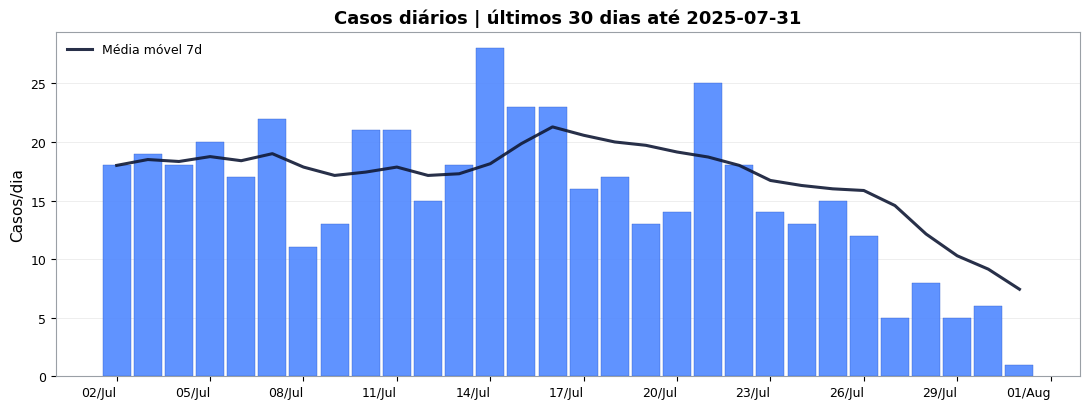

In [30]:
plt.rcParams.update({
        "axes.edgecolor": "#9aa0a6",
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })

fig, ax = plt.subplots(figsize=(11, 4.2))
bars = ax.bar(s_daily.index, s_daily.values, width=0.9,
                  color="#4f87ff", edgecolor="#2a56c6", linewidth=0.3, alpha=0.9)

rolling_days = 7
if rolling_days and rolling_days > 1:
        s_ma = s_daily.rolling(rolling_days, min_periods=1).mean()
        ax.plot(s_ma.index, s_ma.values, linewidth=2.2, color="#101935", alpha=0.9, label=f"Média móvel {rolling_days}d")
        
subtitle = f"(filtro: {where_clause})" if where_clause else ""
ax.set_title(f"Casos diários | últimos 30 dias até {last_date.date()}".strip())
ax.set_xlabel("")
ax.set_ylabel("Casos/dia")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))
ax.tick_params(axis="x", rotation=0)
fig.autofmt_xdate(rotation=0)

# grid leve e formatação de eixo Y
ax.yaxis.grid(True, linewidth=0.6, alpha=0.25)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(FuncFormatter(_fmt_int))

ax.yaxis.grid(True, linewidth=0.6, alpha=0.25)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(FuncFormatter(_fmt_int))


# legenda se houver média
if rolling_days and rolling_days > 1:
    ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

In [32]:
import sqlite3
from pathlib import Path
from typing import Optional

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

In [ ]:
def _fetch_dates_df(
    db_path: str | Path,
    table: str,
    date_col: str,
    where_clause: Optional[str] = None,
) -> pd.DataFrame:
    path = Path(db_path)
    if not path.exists():
        raise FileNotFoundError(f"SQLite não encontrado em: {path.resolve()}")

    where = f"WHERE {where_clause}" if where_clause else ""
    sql = f"""
        SELECT {date_col} AS dt
        FROM {table}
        {where}
        AND {date_col} IS NOT NULL
    """.replace("WHERE  AND", "WHERE ")

    with sqlite3.connect(str(path)) as conn:
        df = pd.read_sql(sql, conn)

    df["dt"] = pd.to_datetime(df["dt"], errors="coerce", dayfirst=True)
    df = df.dropna(subset=["dt"]).sort_values("dt").reset_index(drop=True)
    return df

def _fmt_int(x, _pos=None):
    # 12_300 -> 12,3k
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    if x >= 1_000:
        return f"{x/1_000:.1f}k"
    return f"{int(x):d}"


In [83]:
def plot_monthly_cases_last_12_months(
    db_path: str | Path,
    out_path: str | Path,
    table: str = "srag_data",
    date_col: str = "DT_SIN_PRI",
    where_clause: Optional[str] = None,
    ) -> None:
    df = _fetch_dates_df(db_path, table, date_col, where_clause)
    if df.empty:
        raise ValueError("Nenhum registro com data válida para o filtro informado.")

    last_date = df["dt"].max().normalize()
    last_month = pd.Timestamp(year=last_date.year, month=last_date.month, day=1)
    first_month = (last_month - pd.DateOffset(months=11)).normalize()

    s_monthly = (
        df.set_index("dt")
          .sort_index()
          .groupby(pd.Grouper(freq="MS"))
          .size()
          .rename("casos")
    )
    idx = pd.date_range(first_month, last_month, freq="MS")
    s_monthly = s_monthly.reindex(idx, fill_value=0)
    print(s_monthly)
    monthly_df = s_monthly.to_frame()

    plt.rcParams.update({
        "axes.edgecolor": "#9aa0a6",
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9,
    })

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(10.6, 4.2))

    ax.bar(s_monthly.index, s_monthly.values, width=24, 
           color="#00a37a", edgecolor="#0b5c49", linewidth=0.3, alpha=0.9)

    ax.set_title(
        f"Casos mensais | últimos 12 meses até {last_month.strftime('%Y-%m')}".strip()
    )
    ax.set_xlabel("")
    ax.set_ylabel("Casos/mês")

    # eixo X com rótulos compactos
    ax.set_xticks(s_monthly.index)
    ax.set_xticklabels([ts.strftime("%b/%y") for ts in s_monthly.index], rotation=0)

    ax.yaxis.grid(True, linewidth=0.6, alpha=0.25)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(FuncFormatter(_fmt_int))


    plt.tight_layout()
    fig.savefig(out_path.with_suffix(".png"), dpi=200)
    fig.savefig(out_path.with_suffix(".svg"))
    plt.close(fig)
    return None

In [84]:
teste = plot_monthly_cases_last_12_months(
    'sqlite:///../../data/marts/srag.sqlite', "report/imgs/casos_mensais_12m_covid",
    where_clause="CLASSI_FIN = 5"
)

             dt
0    2024-12-29
1    2024-12-29
2    2024-12-29
3    2024-12-29
4    2024-12-29
...         ...
9277 2025-07-30
9278 2025-07-30
9279 2025-07-30
9280 2025-07-30
9281 2025-07-31

[9282 rows x 1 columns]
2024-08-01       0
2024-09-01       0
2024-10-01       0
2024-11-01       0
2024-12-01     281
2025-01-01    3130
2025-02-01    2593
2025-03-01    1278
2025-04-01     500
2025-05-01     515
2025-06-01     491
2025-07-01     494
Freq: MS, Name: casos, dtype: int64


C:\Users\lineker.aguiar_indic\AppData\Local\Temp\ipykernel_20228\215529631.py:22: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["dt"] = pd.to_datetime(df["dt"], errors="coerce", dayfirst=True)


In [74]:
teste 

,casos
2024-08,0
2024-09,0
2024-10,0
2024-11,0
2024-12,281
2025-01,3130
2025-02,2593
2025-03,1278
2025-04,500
2025-05,515
